In [4]:
from PIL import Image, ImageDraw, ImageFont
import textwrap

def generate_text_image(text, image_size=(800, 600), font_path='Arial.ttf', font_size=50, output_filename="question_image.png"):
    """
    Generates an image with a black background and white text.

    Args:
        text (str): The question or text to display.
        image_size (tuple): A tuple (width, height) for the image size in pixels.
        font_path (str): Path to the TrueType font file.
        font_size (int): Size of the font.
        output_filename (str): Name of the output image file.
    """
    # Create a new black image (RGB mode)
    img = Image.new('RGB', image_size, color = (0, 0, 0)) # Black background
    draw = ImageDraw.Draw(img)

    try:
        # Load the font
        font = ImageFont.truetype(font_path, font_size)
    except IOError:
        print(f"Font file '{font_path}' not found. Using default font.")
        font = ImageFont.load_default()
        font_size = 15 # Adjust default font size

    # Define text color (white)
    text_color = (255, 255, 255)

    # Simple text wrapping to fit within image width (basic approach)
    # A more robust wrapping function might be needed for complex layouts
    max_width = image_size[0] - 20 # Add some padding
    wrapped_text = textwrap.wrap(text, width=int(max_width / (font_size * 0.5))) # Rough estimate for characters per line

    # Calculate text position to center (vertically and horizontally) - basic centering
    # This might not be perfect for all fonts/sizes
    y_text = (image_size[1] - len(wrapped_text) * font_size) / 2
    for line in wrapped_text:
        # Calculate line width for centering
        line_width = draw.textlength(line, font=font)
        x_text = (image_size[0] - line_width) / 2
        draw.text((x_text, y_text), line, font=font, fill=text_color)
        y_text += font_size + 5 # Move to next line

    # Save the image
    img.save(output_filename)
    print(f"Image saved as {output_filename}")

# --- Example Usage ---

# Define the question and desired size
question_text = "What is the capital of France? This is a longer question to test text wrapping."
image_width = 800
image_height = 800

# Call the function to generate the image
generate_text_image(
    text=question_text,
    image_size=(image_width, image_height),
    font_path='Arial.ttf', # Make sure you have this font file
    font_size=100,
    output_filename="my_question.png"
)


Font file 'Arial.ttf' not found. Using default font.
Image saved as my_question.png


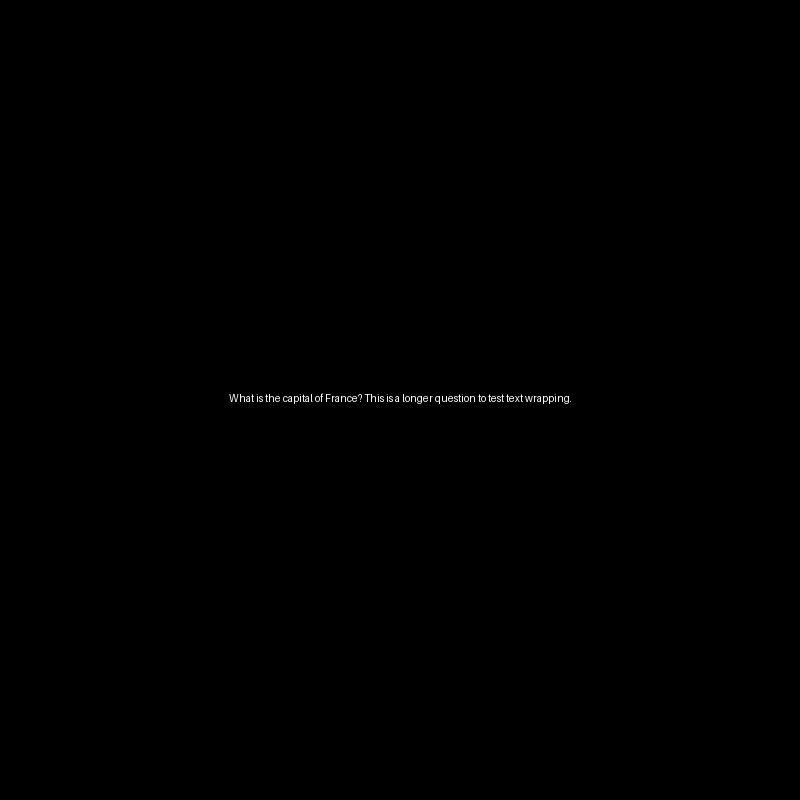

In [9]:
from IPython.display import Image 
pil_img = Image(filename='my_question.png')
display(pil_img)


In [ ]:
from PIL import Image, ImageDraw, ImageFont

# ---------- CONFIG ----------
WIDTH, HEIGHT = 1080, 1920   # Story size
BG_COLOR = (10, 10, 10)      # Dark grey background
TEXT_COLOR = (255, 255, 255)

TEXT = """HuM nE tM kO
SaNsOo mAi TaSbHi
k DaNoO Ki TrHa
PaRrOyA hAi...

"YaAd RaKhO"
Agr ToTtE hUm
BiKhr tM b jAo
gE......

#BROKEN 💔
"""

# FONT_PATH = "seguiemj.ttf"   # Change if needed
FONT_PATH = "Roboto.ttf"   # Change if needed
FONT_SIZE = 100
LINE_SPACING = 18
# ----------------------------

# Create image
img = Image.new("RGB", (WIDTH, HEIGHT), BG_COLOR)
draw = ImageDraw.Draw(img)

# Load font
font = ImageFont.truetype(FONT_PATH, FONT_SIZE)

# Calculate text size
bbox = draw.multiline_textbbox((0, 0), TEXT, font=font, spacing=LINE_SPACING)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]

# Center position
x = (WIDTH - text_width) // 2
y = (HEIGHT - text_height) // 2

# Draw text
draw.multiline_text(
    (x, y),
    TEXT,
    fill=TEXT_COLOR,
    font=font,
    align="center",
    spacing=LINE_SPACING
)

# Save image
img.save("poetry_text_image.png", quality=95)
print("Image generated: poetry_text_image.png")


Image generated: poetry_text_image.png


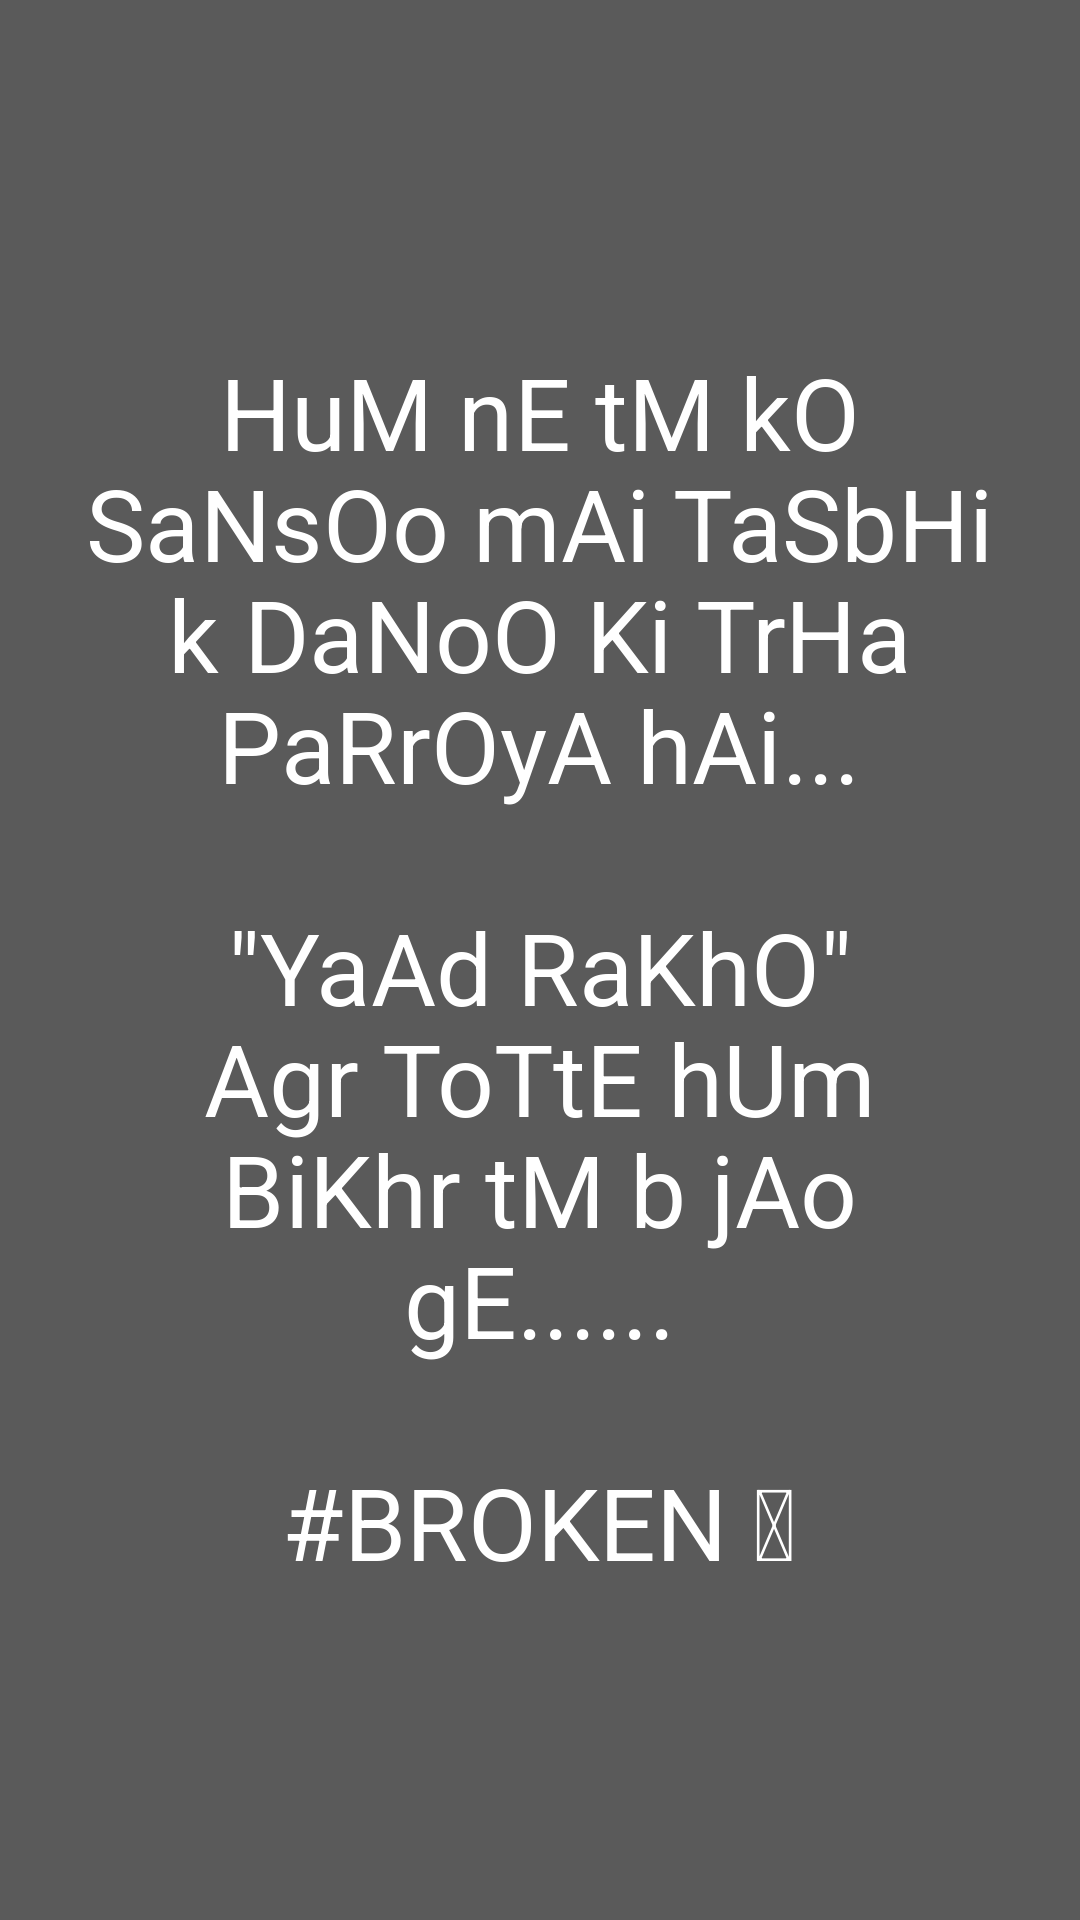

In [10]:
from IPython.display import Image 
pil_img = Image(filename='poetry_text_image.png')
display(pil_img)